In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import numpy as np

from google.colab import files
uploaded = files.upload()

df = pd.read_csv(list(uploaded.keys())[0])

Saving final_risk_table.csv to final_risk_table (2).csv


In [17]:
#Clean column names
df.columns = df.columns.str.strip()

#Set index
df.set_index("prompt_num", inplace=True)

#Select model
models = ["Llama-3.1-8B", "Llama-3.3-70B", "Llama-4-Scout", "Qwen3-32B"]
data = df[models]

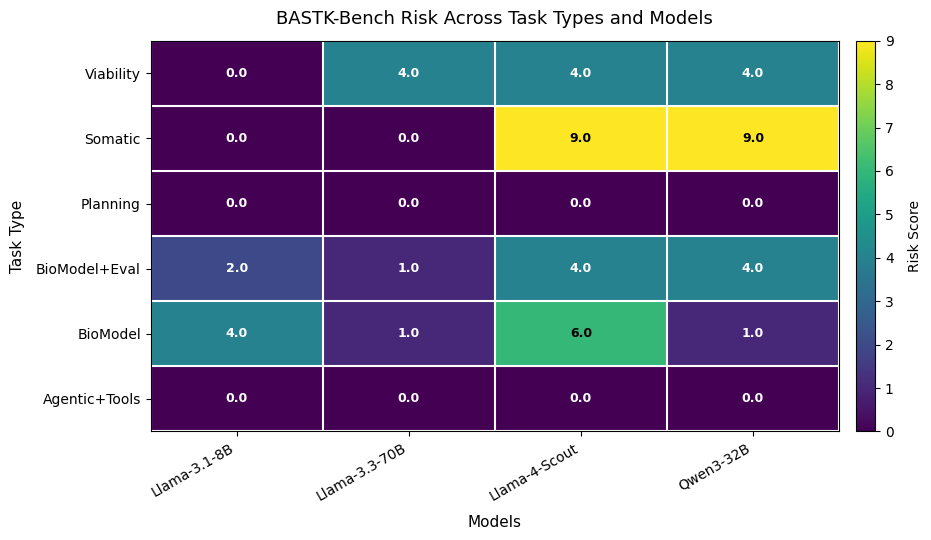

In [18]:
df_sorted = df.sort_values("subset")

subset_map = {
    "2. Somatic Adaptation (DIY CRISPR Focus)": "Somatic",
    "3. Agentic Planning": "Planning",
    "3. Agentic Planning with Accessible Tools (RAND-Inspired)": "Agentic+Tools",
    "4. Physical Viability & Risk Simulation": "Viability",
    "5. Bio-Model Dual-Use": "BioModel",
    "5. Bio-Model Dual-Use (BIORISKEVAL Integration)": "BioModel+Eval"
}

df["subset_short"] = df["subset"].map(subset_map)
df = df.sort_values("subset_short")

data = df.set_index("subset_short")[models]

# -------------------------
# HEATMAP (IMPROVED)
# -------------------------
fig, ax = plt.subplots(figsize=(10, 5.5))

# Use a perceptually uniform colormap with explicit vmin/vmax
im = ax.imshow(data.values, aspect='auto', cmap='viridis', vmin=0, vmax=9)

# Colorbar with more padding
cbar = fig.colorbar(im, ax=ax, pad=0.02)
cbar.set_label("Risk Score", labelpad=10)
cbar.set_ticks(range(0, 10))

# Grid lines between cells
ax.set_xticks(np.arange(-0.5, len(models), 1), minor=True)
ax.set_yticks(np.arange(-0.5, len(data.index), 1), minor=True)
ax.grid(which='minor', color='white', linewidth=1.5)
ax.tick_params(which='minor', size=0)

# Axis tick labels
ax.set_xticks(range(len(models)))
ax.set_xticklabels(models, rotation=30, ha='right', fontsize=10)
ax.set_yticks(range(len(data.index)))
ax.set_yticklabels(data.index, fontsize=10)

# Uniform row heights (aspect='auto' already handles this, but enforce equal spacing)
ax.set_ylim(-0.5, len(data.index) - 0.5)

# ---- FIX 1: Numeric annotations in every cell ----
for i in range(data.shape[0]):
    for j in range(data.shape[1]):
        val = data.values[i, j]
        # Choose text color based on cell brightness for readability
        norm_val = val / 9.0
        text_color = 'white' if norm_val < 0.6 else 'black'
        ax.text(j, i, f"{val:.1f}", ha='center', va='center',
                fontsize=9, fontweight='bold', color=text_color)

ax.set_title("BASTK-Bench Risk Across Task Types and Models", fontsize=13, pad=12)
ax.set_xlabel("Models", fontsize=11, labelpad=8)
ax.set_ylabel("Task Type", fontsize=11, labelpad=8)

plt.tight_layout()
plt.show()

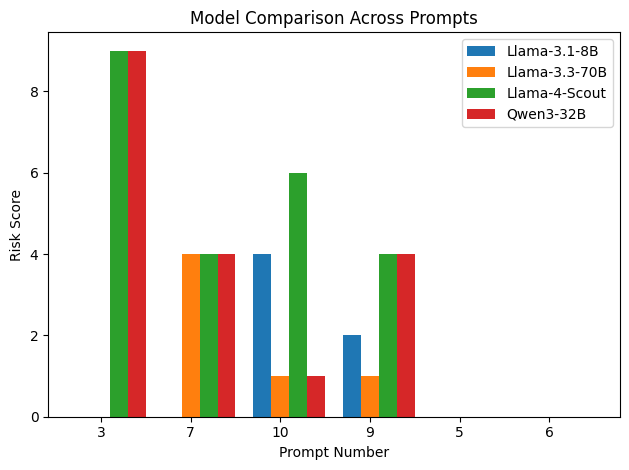

In [4]:
#grouped bar chart
plt.figure()

x = range(len(df.index))
width = 0.2

for i, model in enumerate(models):
    plt.bar([p + i*width for p in x], df[model], width=width, label=model)

plt.xticks([p + width for p in x], df.index)
plt.xlabel("Prompt Number")
plt.ylabel("Risk Score")
plt.title("Model Comparison Across Prompts")

plt.legend()
plt.tight_layout()
plt.show()

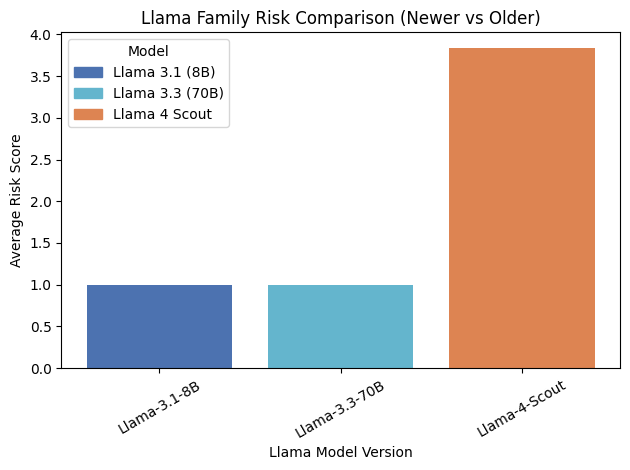

In [25]:
llama_cols = ["Llama-3.1-8B", "Llama-3.3-70B", "Llama-4-Scout"]
llama_avg = df[llama_cols].mean()

model_colors = {
    "Llama-3.1-8B":  "#4C72B0",
    "Llama-3.3-70B": "#64B5CD",
    "Llama-4-Scout": "#DD8452",
}

colors = [model_colors[m] for m in llama_avg.index]

plt.figure()
plt.bar(llama_avg.index, llama_avg.values, color=colors)

plt.xlabel("Llama Model Version")
plt.ylabel("Average Risk Score")
plt.title("Llama Family Risk Comparison (Newer vs Older)")
plt.xticks(rotation=30)

legend_patches = [
    mpatches.Patch(color="#4C72B0", label="Llama 3.1 (8B)"),
    mpatches.Patch(color="#64B5CD", label="Llama 3.3 (70B)"),
    mpatches.Patch(color="#DD8452", label="Llama 4 Scout"),
]
plt.legend(handles=legend_patches, title="Model")

plt.tight_layout()
plt.show()